# Phase 3 — Block-Sparse Triton Kernel

Take the ActW-30% pruned model (our best moderate-sparsity variant) and build a custom Triton kernel that **actually skips the zeroed tiles** at runtime.

Pipeline:
1. Load model, run ActW calibration, compute 30% pruning masks (capped at 50% per matrix).
2. For each MLP linear: convert dense weight + mask into a BCSR-style representation (packed non-zero tiles + bitmap).
3. Write a Triton block-sparse matmul that reads the bitmap and skips zeroed (n_tile, k_tile) blocks.
4. Wrap in a `BlockSparseLinear` module, swap in for `nn.Linear` on MLP layers.
5. Validate correctness against the dense-pruned model, then benchmark latency/throughput/memory.

Open question we're answering: **does block-sparse actually beat dense on modern GPUs at ~30% sparsity?**

In [1]:
import torch
import torch.nn as nn
import numpy as np
import triton
import triton.language as tl
import matplotlib.pyplot as plt
from collections import defaultdict
from transformers import AutoModelForCausalLM, AutoTokenizer
import time, gc, re

import config

torch.set_float32_matmul_precision("high")
plt.rcParams["figure.dpi"] = 120
print(f"torch: {torch.__version__}  triton: {triton.__version__}")
print(f"device: {torch.cuda.get_device_name(0)}")

torch: 2.6.0+cu124  triton: 3.2.0
device: NVIDIA GeForce RTX 4070 Laptop GPU


## 1. Load model + tokenizer

In [2]:
print(f"Loading {config.MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    config.MODEL_NAME,
    torch_dtype=getattr(torch, config.TORCH_DTYPE),
    device_map=config.DEVICE,
)
model.eval()

TILE_R, TILE_C = config.TILE_SIZES[0]
print(f"tile size: ({TILE_R}, {TILE_C})")
print(f"params: {sum(p.numel() for p in model.parameters())/1e9:.2f}B")

Loading google/gemma-3-1b-it...
tile size: (128, 128)
params: 1.00B


## 2. ActW calibration + 30% pruning masks

Reuse the scoring approach from the main notebook: Frobenius norm per tile * mean input activation norm per tile column, normalized per component type, global threshold at 30% with a 50% per-matrix cap.

In [3]:
from datasets import load_dataset
from tqdm import tqdm

def is_mlp(name):
    return any(k in name for k in config.PRUNE_TARGETS_PATTERNS)

def get_component_type(name):
    for p in config.PRUNE_TARGETS_PATTERNS:
        if p in name:
            return p
    return "unknown"

def compute_tile_frob(W, tr=TILE_R, tc=TILE_C):
    W = W.detach().float().cpu()
    out_dim, in_dim = W.shape
    nr, nc = out_dim // tr, in_dim // tc
    Wt = W[:nr*tr, :nc*tc].reshape(nr, tr, nc, tc).permute(0, 2, 1, 3)
    return Wt.reshape(nr, nc, -1).norm(dim=-1).numpy()

# --- Load calibration data ---
print("Loading calibration data...")
cal_ds = load_dataset(
    config.CALIBRATION_DATASET,
    config.CALIBRATION_SUBSET,
    split="train",
    streaming=True,
    trust_remote_code=True,
)
cal_texts = []
for i, ex in enumerate(cal_ds):
    if i >= config.CALIBRATION_SAMPLES:
        break
    t = ex.get("text", "")
    if len(t) > 50:
        cal_texts.append(t)
cal_encodings = [
    tokenizer(t, return_tensors="pt", max_length=config.CALIBRATION_SEQ_LEN, truncation=True)
    for t in cal_texts
]
print(f"loaded {len(cal_encodings)} samples")

Loading calibration data...


Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

loaded 1022 samples


In [4]:
# --- Compute Frobenius tile importance ---
importance_frob = {}
for name, param in model.named_parameters():
    if param.ndim != 2 or not is_mlp(name):
        continue
    importance_frob[name] = compute_tile_frob(param)
print(f"frob scored: {len(importance_frob)} matrices")

# --- Activation-norm hooks ---
activation_stats = {}
hooks = []

def make_hook(pname, in_dim):
    nc = in_dim // TILE_C
    def h(mod, inp, out):
        x = inp[0].detach().float().reshape(-1, inp[0].shape[-1])
        x = x[:, :nc*TILE_C].reshape(x.shape[0], nc, TILE_C)
        cn = x.norm(dim=-1).mean(dim=0).cpu()
        if pname not in activation_stats:
            activation_stats[pname] = (cn, 1)
        else:
            s, c = activation_stats[pname]
            activation_stats[pname] = (s + cn, c + 1)
    return h

for name, module in model.named_modules():
    if not isinstance(module, nn.Linear):
        continue
    pn = name + ".weight"
    if not is_mlp(pn) or module.in_features < TILE_C:
        continue
    hooks.append(module.register_forward_hook(make_hook(pn, module.in_features)))

print(f"running calibration on {len(cal_encodings)} samples (forward only)...")
with torch.no_grad():
    for enc in tqdm(cal_encodings, desc="calib"):
        model(**{k: v.to(config.DEVICE) for k, v in enc.items()})
for h in hooks:
    h.remove()
print(f"activation stats collected for {len(activation_stats)} matrices")

frob scored: 78 matrices
running calibration on 1022 samples (forward only)...


calib: 100%|█████████████████████████████████████████████████████| 1022/1022 [00:53<00:00, 19.24it/s]

activation stats collected for 78 matrices


In [5]:
# --- Activation-weighted importance + per-component-type z-score ---
importance_actw = {}
for name, fmap in importance_frob.items():
    if name not in activation_stats:
        continue
    cn, count = activation_stats[name]
    importance_actw[name] = fmap * (cn / count).numpy()[np.newaxis, :]

comp_stats = {}
for ct in config.PRUNE_TARGETS_PATTERNS:
    vals = np.concatenate([m.ravel() for n, m in importance_actw.items() if ct in n])
    comp_stats[ct] = (vals.mean(), vals.std())

importance_actw_norm = {}
for name, m in importance_actw.items():
    mu, sd = comp_stats[get_component_type(name)]
    importance_actw_norm[name] = (m - mu) / sd if sd > 1e-8 else np.zeros_like(m)

# --- Global 30% threshold + 50% per-matrix cap ---
PRUNE_RATIO = 0.30
all_scores = np.concatenate([m.ravel() for m in importance_actw_norm.values()])
threshold = float(np.percentile(all_scores, PRUNE_RATIO * 100))

def capped_mask(norm_map, thresh, max_prune=config.MAX_PRUNE_PER_MATRIX):
    gm = norm_map < thresh
    if gm.mean() <= max_prune:
        return gm
    local = float(np.percentile(norm_map.ravel(), max_prune * 100))
    return norm_map < local

prune_masks = {name: capped_mask(m, threshold) for name, m in importance_actw_norm.items()}

total_tiles = sum(m.size for m in prune_masks.values())
total_pruned = sum(m.sum() for m in prune_masks.values())
print(f"global threshold: {threshold:.4f}")
print(f"pruned: {total_pruned}/{total_tiles} ({100*total_pruned/total_tiles:.1f}%)")
capped = sum(1 for name, m in importance_actw_norm.items() if (m < threshold).mean() > config.MAX_PRUNE_PER_MATRIX)
print(f"matrices hit cap: {capped}/{len(prune_masks)}")

global threshold: -0.5027
pruned: 7966/37908 (21.0%)
matrices hit cap: 25/78


## 3. Triton block-sparse matmul kernel

Standard `nn.Linear` forward: `y = x @ W.T + b` where `W` is `(out_features, in_features)`.

Tile `W` into `(BLOCK_N, BLOCK_K)` blocks matching our `(TILE_R, TILE_C) = (128, 128)`.
A bitmap `nonzero[n_tile, k_tile]` tells the kernel whether to compute that block.

The kernel launches a 2D grid `(ceil(M/BLOCK_M), ceil(N/BLOCK_N))`. For each output block it accumulates over `K`, **skipping tiles whose bitmap entry is 0**.

In [6]:
@triton.jit
def block_sparse_matmul_kernel(
    X_ptr, W_ptr, Y_ptr, bitmap_ptr,
    M, N, K,
    stride_xm, stride_xk,
    stride_wn, stride_wk,
    stride_ym, stride_yn,
    stride_bn, stride_bk,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_k = tl.arange(0, BLOCK_K)

    x_ptrs = X_ptr + offs_m[:, None] * stride_xm + offs_k[None, :] * stride_xk
    w_ptrs = W_ptr + offs_n[:, None] * stride_wn + offs_k[None, :] * stride_wk

    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    n_k_tiles = tl.cdiv(K, BLOCK_K)

    for k_tile in range(n_k_tiles):
        # bitmap lookup: 1 = keep, 0 = skip entire (N_tile x K_tile) block
        nz = tl.load(bitmap_ptr + pid_n * stride_bn + k_tile * stride_bk)
        if nz != 0:
            k_start = k_tile * BLOCK_K
            x_mask = (offs_m[:, None] < M) & ((offs_k[None, :] + k_start) < K)
            w_mask = (offs_n[:, None] < N) & ((offs_k[None, :] + k_start) < K)
            x = tl.load(x_ptrs, mask=x_mask, other=0.0)
            w = tl.load(w_ptrs, mask=w_mask, other=0.0)
            acc += tl.dot(x, tl.trans(w))
        x_ptrs += BLOCK_K * stride_xk
        w_ptrs += BLOCK_K * stride_wk

    y_ptrs = Y_ptr + offs_m[:, None] * stride_ym + offs_n[None, :] * stride_yn
    y_mask = (offs_m[:, None] < M) & (offs_n[None, :] < N)
    tl.store(y_ptrs, acc.to(Y_ptr.dtype.element_ty), mask=y_mask)


def block_sparse_matmul(x, w, bitmap, block_m=64, block_n=TILE_R, block_k=TILE_C):
    """
    x: (M, K)  input activations
    w: (N, K)  dense weight (zeroed tiles still in memory for v1)
    bitmap: (N // block_n, K // block_k) int8, 1 = keep, 0 = skip
    returns y: (M, N)
    """
    assert x.shape[1] == w.shape[1]
    M, K = x.shape
    N, _ = w.shape
    y = torch.empty((M, N), device=x.device, dtype=x.dtype)

    grid = (triton.cdiv(M, block_m), triton.cdiv(N, block_n))
    block_sparse_matmul_kernel[grid](
        x, w, y, bitmap,
        M, N, K,
        x.stride(0), x.stride(1),
        w.stride(0), w.stride(1),
        y.stride(0), y.stride(1),
        bitmap.stride(0), bitmap.stride(1),
        BLOCK_M=block_m, BLOCK_N=block_n, BLOCK_K=block_k,
    )
    return y

print("kernel compiled (JIT — first call triggers compilation)")

kernel compiled (JIT — first call triggers compilation)


## 4. Correctness test — kernel vs torch.matmul

Generate a random W, apply a random tile mask to it, then verify that the Triton kernel produces the same result as `x @ (W * mask_expanded).T`.

In [7]:
torch.manual_seed(0)
M, N, K = 256, 1024, 1152  # arbitrary sizes, multiples of 128
dtype = torch.bfloat16

x = torch.randn(M, K, device="cuda", dtype=dtype)
w = torch.randn(N, K, device="cuda", dtype=dtype) * 0.1

# Random 30% tile mask
n_tiles_n = N // TILE_R
n_tiles_k = K // TILE_C
mask_np = (np.random.rand(n_tiles_n, n_tiles_k) > 0.30).astype(np.int8)
bitmap = torch.from_numpy(mask_np).to("cuda").contiguous()

# Apply mask to w to produce the "dense-pruned" reference
w_masked = w.clone()
for i in range(n_tiles_n):
    for j in range(n_tiles_k):
        if mask_np[i, j] == 0:
            w_masked[i*TILE_R:(i+1)*TILE_R, j*TILE_C:(j+1)*TILE_C] = 0

# Reference: pure torch matmul on the zeroed weight
y_ref = x @ w_masked.T

# Triton kernel: uses original w + bitmap to skip zeroed tiles
y_triton = block_sparse_matmul(x, w, bitmap)

diff = (y_ref - y_triton).abs()
print(f"max abs diff: {diff.max().item():.5f}")
print(f"mean abs diff: {diff.mean().item():.6f}")
print(f"|y_ref| mean:  {y_ref.abs().mean().item():.4f}")
# Tolerance is loose because bf16 accumulation order differs between kernels
assert diff.max().item() < 0.5, f"kernel mismatch: max diff {diff.max().item()}"
print("correctness: OK")

max abs diff: 0.00000
mean abs diff: 0.000000
|y_ref| mean:  2.2188
correctness: OK


## 5. `BlockSparseLinear` module

Drop-in replacement for `nn.Linear` that stores the dense weight plus a bitmap, and uses the Triton kernel for forward pass.

In [8]:
class BlockSparseLinear(nn.Module):
    """
    Drop-in for nn.Linear with block-sparse weight (zeroed tiles skipped in kernel).
    v1: keeps the dense weight in memory (doesn't pack), relying on the bitmap
    to skip compute. Compute savings are real; memory savings require BCSR packing
    (future work).

    Hybrid dispatch: below SMALL_M_THRESHOLD the kernel loses to cuBLAS (memory-bw
    bound at M=1), so we fall back to dense matmul. The stored weight already has
    pruned tiles zeroed, so dense gives the same result — just without the skip.
    """
    SMALL_M_THRESHOLD = 64  # M values below this use dense; tune empirically

    def __init__(self, in_features, out_features, bitmap, weight, bias=None,
                 tile_r=TILE_R, tile_c=TILE_C, small_m_threshold=None):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.tile_r = tile_r
        self.tile_c = tile_c
        self.small_m_threshold = (small_m_threshold if small_m_threshold is not None
                                  else self.SMALL_M_THRESHOLD)
        self.register_buffer("weight", weight.contiguous())
        self.register_buffer("bitmap", bitmap.contiguous())
        if bias is not None:
            self.register_buffer("bias", bias.contiguous())
        else:
            self.bias = None

    def forward(self, x):
        orig_shape = x.shape
        x2 = x.reshape(-1, orig_shape[-1])
        M = x2.shape[0]

        if M < self.small_m_threshold:
            # Decode path: dense matmul (weight already zeroed → same result, no regression)
            y = x2 @ self.weight.T
        else:
            # Prefill path: block-sparse kernel skips zeroed-tile compute
            if not x2.is_contiguous():
                x2 = x2.contiguous()
            y = block_sparse_matmul(x2, self.weight, self.bitmap,
                                    block_n=self.tile_r, block_k=self.tile_c)
        if self.bias is not None:
            y = y + self.bias
        return y.reshape(*orig_shape[:-1], self.out_features)

    @classmethod
    def from_dense(cls, linear: nn.Linear, prune_mask: np.ndarray,
                   tile_r=TILE_R, tile_c=TILE_C):
        """Build a BlockSparseLinear from a dense nn.Linear and a prune_mask.
        prune_mask[i, j] == True means tile (i, j) should be zeroed."""
        out_f, in_f = linear.weight.shape
        nr, nc = out_f // tile_r, in_f // tile_c
        keep = (~prune_mask[:nr, :nc]).astype(np.int8)
        bitmap = torch.from_numpy(keep).to(linear.weight.device)

        # Zero out the pruned tiles in the weight we store
        w = linear.weight.detach().clone()
        for i in range(nr):
            for j in range(nc):
                if prune_mask[i, j]:
                    w[i*tile_r:(i+1)*tile_r, j*tile_c:(j+1)*tile_c] = 0

        b = linear.bias.detach().clone() if linear.bias is not None else None
        return cls(in_f, out_f, bitmap, w, b, tile_r=tile_r, tile_c=tile_c)

print("BlockSparseLinear ready (hybrid dispatch: dense for M<64, block-sparse for M>=64)")

BlockSparseLinear ready (hybrid dispatch: dense for M<64, block-sparse for M>=64)


In [9]:
# Validate BlockSparseLinear against plain nn.Linear with zeroed weight
torch.manual_seed(1)
lin = nn.Linear(1152, 1024, bias=False).to("cuda").to(dtype)
mask = np.random.rand(1024 // TILE_R, 1152 // TILE_C) < 0.30
bsl = BlockSparseLinear.from_dense(lin, mask)

# Dense-pruned reference
lin_pruned = nn.Linear(1152, 1024, bias=False).to("cuda").to(dtype)
with torch.no_grad():
    w_ref = lin.weight.clone()
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j]:
                w_ref[i*TILE_R:(i+1)*TILE_R, j*TILE_C:(j+1)*TILE_C] = 0
    lin_pruned.weight.copy_(w_ref)

x_test = torch.randn(8, 64, 1152, device="cuda", dtype=dtype)
y_ref = lin_pruned(x_test)
y_bsl = bsl(x_test)
print(f"shape match: {y_ref.shape == y_bsl.shape}  ({tuple(y_bsl.shape)})")
print(f"max diff: {(y_ref - y_bsl).abs().max().item():.4f}")
print(f"mean diff: {(y_ref - y_bsl).abs().mean().item():.5f}")

shape match: True  ((8, 64, 1024))
max diff: 0.0000
mean diff: 0.00000


## 6. Swap `nn.Linear` → `BlockSparseLinear` in the model

Walk the model, find MLP linears, build a `BlockSparseLinear` from each one + its prune_mask, and replace it in-place.

In [10]:
def get_parent_and_attr(root, dotted_name):
    parts = dotted_name.split(".")
    parent = root
    for p in parts[:-1]:
        parent = getattr(parent, p)
    return parent, parts[-1]

# Keep a reference to original MLP linears so we can restore dense later if needed
original_mlp = {}
swapped_count = 0

for name, module in list(model.named_modules()):
    if not isinstance(module, nn.Linear):
        continue
    pname = name + ".weight"
    if pname not in prune_masks:
        continue
    mask = prune_masks[pname]
    original_mlp[name] = module  # reference, not copy
    bsl = BlockSparseLinear.from_dense(module, mask).to("cuda")
    parent, attr = get_parent_and_attr(model, name)
    setattr(parent, attr, bsl)
    swapped_count += 1

torch.cuda.empty_cache()
print(f"swapped {swapped_count} MLP linears to BlockSparseLinear")
print(f"peak GPU memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

swapped 78 MLP linears to BlockSparseLinear
peak GPU memory: 3.30 GB


## 7. Sanity check — generation still works

In [11]:
prompt = "The capital of France is"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=20, do_sample=False)
print(tokenizer.decode(out[0], skip_special_tokens=True))

/home/cmoryah/anaconda3/envs/chatbot/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/cmoryah/anaconda3/envs/chatbot/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `64` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


The capital of France is a popular destination for tourists.

**The French** is a popular destination for tourists.

**


## 8. MMLU eval on block-sparse model

Should match the dense-pruned ActW 30% result (~28.1%).

In [12]:
from eval_mmlu import evaluate, print_results, save_results

t0 = time.time()
results_bs = evaluate(model, tokenizer, tag="block_sparse_actw_30pct")
elapsed = time.time() - t0
results_bs["meta"] = {
    "method": "actw",
    "prune_ratio": 0.30,
    "kernel": "block_sparse_triton",
    "eval_time_s": round(elapsed, 1),
}
print_results(results_bs)
save_results(results_bs)

[block_sparse_actw_30pct] MMLU subjects: 100%|███████████████████████| 10/10 [01:13<00:00,  7.32s/it]


  MMLU Results — block_sparse_actw_30pct
  abstract_algebra               ████░░░░░░░░░░░░░░░░  24.0% (24/100)
  anatomy                        ████░░░░░░░░░░░░░░░░  22.2% (30/135)
  college_chemistry              ██████░░░░░░░░░░░░░░  34.0% (34/100)
  college_computer_science       █████░░░░░░░░░░░░░░░  29.0% (29/100)
  econometrics                   █████░░░░░░░░░░░░░░░  27.2% (31/114)
  global_facts                   ███░░░░░░░░░░░░░░░░░  16.0% (16/100)
  machine_learning               ████░░░░░░░░░░░░░░░░  24.1% (27/112)
  moral_scenarios                █████░░░░░░░░░░░░░░░  27.3% (244/895)
  professional_medicine          ████████░░░░░░░░░░░░  41.5% (113/272)
  us_foreign_policy              █████░░░░░░░░░░░░░░░  28.0% (28/100)
────────────────────────────────────────────────────────────
  OVERALL                                       28.4% (576/2028)

Results saved to results/mmlu_block_sparse_actw_30pct.json


PosixPath('results/mmlu_block_sparse_actw_30pct.json')

## 9. Kernel benchmark — dense torch.mm vs block-sparse Triton

Strip down to a single MLP-sized matmul and measure wall time at the sparsity levels we care about.

`gate_proj` / `up_proj` are `(6912, 1152)`; `down_proj` is `(1152, 6912)`. We time both.

In [13]:
def bench_matmul(x, w, bitmap=None, n_warmup=10, n_iter=50):
    torch.cuda.synchronize()
    for _ in range(n_warmup):
        if bitmap is None:
            _ = x @ w.T
        else:
            _ = block_sparse_matmul(x, w, bitmap)
    torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_iter):
        if bitmap is None:
            _ = x @ w.T
        else:
            _ = block_sparse_matmul(x, w, bitmap)
    torch.cuda.synchronize()
    return (time.time() - t0) / n_iter * 1000  # ms per iter

shapes = [
    ("gate/up_proj", 1152, 6912),  # in_f, out_f
    ("down_proj",    6912, 1152),
]
seq_lens = [128, 512, 2048]
sparsities = [0.0, 0.10, 0.30, 0.50]

rows = []
for sname, in_f, out_f in shapes:
    for S in seq_lens:
        x_bench = torch.randn(S, in_f, device="cuda", dtype=dtype)
        w_bench = torch.randn(out_f, in_f, device="cuda", dtype=dtype) * 0.1
        dense_ms = bench_matmul(x_bench, w_bench)
        for sp in sparsities:
            if sp == 0.0:
                rows.append((sname, S, sp, dense_ms, "dense", 1.0))
                continue
            nn_t = out_f // TILE_R
            nk_t = in_f // TILE_C
            bm = (np.random.rand(nn_t, nk_t) > sp).astype(np.int8)
            # zero the corresponding tiles in the weight (kernel still skips via bitmap)
            w_zero = w_bench.clone()
            for i in range(nn_t):
                for j in range(nk_t):
                    if bm[i, j] == 0:
                        w_zero[i*TILE_R:(i+1)*TILE_R, j*TILE_C:(j+1)*TILE_C] = 0
            bitmap = torch.from_numpy(bm).to("cuda").contiguous()
            sp_ms = bench_matmul(x_bench, w_zero, bitmap)
            rows.append((sname, S, sp, sp_ms, "block_sparse", dense_ms / sp_ms))

print(f"{'shape':<15} {'seq':>5} {'sparsity':>10} {'ms':>8} {'kind':>12} {'speedup':>8}")
for sname, S, sp, ms, kind, sx in rows:
    print(f"{sname:<15} {S:>5} {sp*100:>9.0f}% {ms:>8.3f} {kind:>12} {sx:>8.2f}x")

shape             seq   sparsity       ms         kind  speedup
gate/up_proj      128         0%    0.065        dense     1.00x
gate/up_proj      128        10%    0.088 block_sparse     0.74x
gate/up_proj      128        30%    0.062 block_sparse     1.05x
gate/up_proj      128        50%    0.044 block_sparse     1.47x
gate/up_proj      512         0%    0.193        dense     1.00x
gate/up_proj      512        10%    0.212 block_sparse     0.91x
gate/up_proj      512        30%    0.176 block_sparse     1.09x
gate/up_proj      512        50%    0.125 block_sparse     1.55x
gate/up_proj     2048         0%    0.817        dense     1.00x
gate/up_proj     2048        10%    1.007 block_sparse     0.81x
gate/up_proj     2048        30%    0.783 block_sparse     1.04x
gate/up_proj     2048        50%    0.582 block_sparse     1.41x
down_proj         128         0%    0.061        dense     1.00x
down_proj         128        10%    0.181 block_sparse     0.34x
down_proj         128     

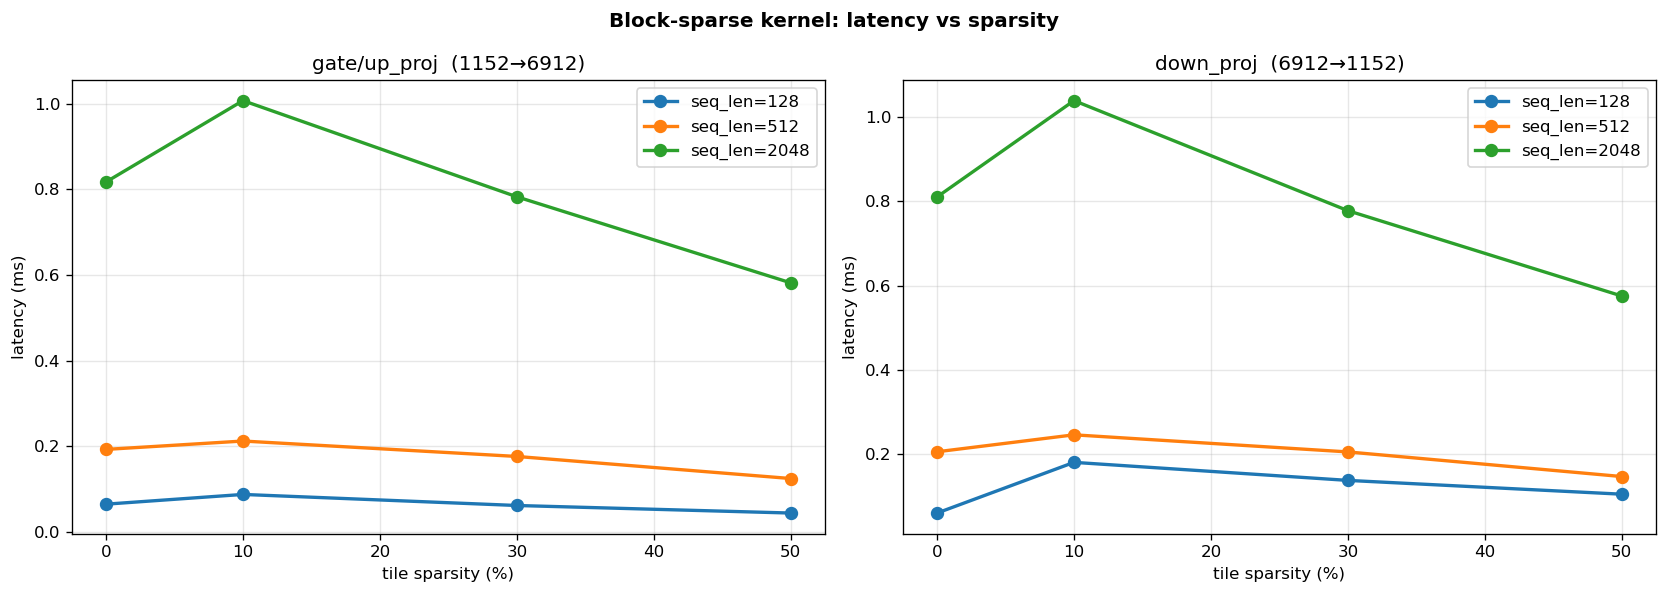

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (sname, in_f, out_f) in zip(axes, shapes):
    for S in seq_lens:
        xs = [r[2]*100 for r in rows if r[0]==sname and r[1]==S]
        ys = [r[3] for r in rows if r[0]==sname and r[1]==S]
        ax.plot(xs, ys, "o-", label=f"seq_len={S}", linewidth=2, markersize=7)
    ax.set_xlabel("tile sparsity (%)")
    ax.set_ylabel("latency (ms)")
    ax.set_title(f"{sname}  ({in_f}→{out_f})")
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.suptitle("Block-sparse kernel: latency vs sparsity", fontweight="bold")
plt.tight_layout()
plt.show()

## 9b. Decode diagnostic — the kernel at M=1

The microbenchmark above used `seq_len ∈ {128, 512, 2048}`, which looks like *prefill*. Autoregressive decode is completely different — every new token passes `M=1` through every MLP linear. With `BLOCK_M=64` we compute 64 output rows for every 1 row we actually need: ~98% wasted work per kernel launch.

Let's measure at realistic decode sizes: `M ∈ {1, 4, 16, 64}` on the actual MLP shapes, dense vs block-sparse at 20/30/50%.

In [15]:
# Benchmark kernel at decode-scale M values
decode_shapes = [
    ("gate/up_proj", 1152, 6912),
    ("down_proj",    6912, 1152),
]
decode_Ms = [1, 4, 16, 64]
decode_sparsities = [0.0, 0.20, 0.30, 0.50]

decode_rows = []
for sname, in_f, out_f in decode_shapes:
    for M_test in decode_Ms:
        x_bench = torch.randn(M_test, in_f, device="cuda", dtype=dtype)
        w_bench = torch.randn(out_f, in_f, device="cuda", dtype=dtype) * 0.1
        dense_ms = bench_matmul(x_bench, w_bench)
        for sp in decode_sparsities:
            if sp == 0.0:
                decode_rows.append((sname, M_test, sp, dense_ms, "dense", 1.0))
                continue
            nn_t = out_f // TILE_R
            nk_t = in_f // TILE_C
            bm = (np.random.rand(nn_t, nk_t) > sp).astype(np.int8)
            w_zero = w_bench.clone()
            for i in range(nn_t):
                for j in range(nk_t):
                    if bm[i, j] == 0:
                        w_zero[i*TILE_R:(i+1)*TILE_R, j*TILE_C:(j+1)*TILE_C] = 0
            bitmap_t = torch.from_numpy(bm).to("cuda").contiguous()
            sp_ms = bench_matmul(x_bench, w_zero, bitmap_t)
            decode_rows.append((sname, M_test, sp, sp_ms, "block_sparse", dense_ms / sp_ms))

print(f"{'shape':<15} {'M':>4} {'sp':>5} {'ms':>8} {'kind':>12} {'vs_dense':>9}")
for sname, M_test, sp, ms, kind, sx in decode_rows:
    print(f"{sname:<15} {M_test:>4} {sp*100:>4.0f}% {ms:>8.3f} {kind:>12} {sx:>8.2f}x")

shape              M    sp       ms         kind  vs_dense
gate/up_proj       1    0%    0.025        dense     1.00x
gate/up_proj       1   20%    0.041 block_sparse     0.60x
gate/up_proj       1   30%    0.038 block_sparse     0.65x
gate/up_proj       1   50%    0.031 block_sparse     0.80x
gate/up_proj       4    0%    0.020        dense     1.00x
gate/up_proj       4   20%    0.041 block_sparse     0.48x
gate/up_proj       4   30%    0.038 block_sparse     0.52x
gate/up_proj       4   50%    0.034 block_sparse     0.59x
gate/up_proj      16    0%    0.021        dense     1.00x
gate/up_proj      16   20%    0.041 block_sparse     0.51x
gate/up_proj      16   30%    0.035 block_sparse     0.60x
gate/up_proj      16   50%    0.029 block_sparse     0.72x
gate/up_proj      64    0%    0.036        dense     1.00x
gate/up_proj      64   20%    0.041 block_sparse     0.87x
gate/up_proj      64   30%    0.040 block_sparse     0.89x
gate/up_proj      64   50%    0.034 block_sparse     1.0

## 9c. Autotuned kernel — tune `BLOCK_M` for small M

`BLOCK_N` and `BLOCK_K` stay fixed at `TILE_R=TILE_C=128` because the bitmap is indexed at that granularity. But `BLOCK_M` is free to vary — and the optimal value depends on `M`. For `M=1` we want `BLOCK_M=16` (Triton's `tl.dot` minimum); for prefill we want `BLOCK_M=64` or `128`.

Wrap the kernel in `@triton.autotune` keyed on `(M, N, K)` so it picks the right config per shape on the first call.

In [16]:
@triton.autotune(
    configs=[
        triton.Config({'BLOCK_M': 16},  num_warps=2, num_stages=2),
        triton.Config({'BLOCK_M': 16},  num_warps=4, num_stages=2),
        triton.Config({'BLOCK_M': 32},  num_warps=2, num_stages=3),
        triton.Config({'BLOCK_M': 32},  num_warps=4, num_stages=3),
        triton.Config({'BLOCK_M': 64},  num_warps=4, num_stages=3),
        triton.Config({'BLOCK_M': 64},  num_warps=8, num_stages=3),
        triton.Config({'BLOCK_M': 128}, num_warps=8, num_stages=3),
    ],
    key=['M', 'N', 'K'],
)
@triton.jit
def block_sparse_matmul_kernel_auto(
    X_ptr, W_ptr, Y_ptr, bitmap_ptr,
    M, N, K,
    stride_xm, stride_xk,
    stride_wn, stride_wk,
    stride_ym, stride_yn,
    stride_bn, stride_bk,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_k = tl.arange(0, BLOCK_K)

    x_ptrs = X_ptr + offs_m[:, None] * stride_xm + offs_k[None, :] * stride_xk
    w_ptrs = W_ptr + offs_n[:, None] * stride_wn + offs_k[None, :] * stride_wk

    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    n_k_tiles = tl.cdiv(K, BLOCK_K)

    for k_tile in range(n_k_tiles):
        nz = tl.load(bitmap_ptr + pid_n * stride_bn + k_tile * stride_bk)
        if nz != 0:
            k_start = k_tile * BLOCK_K
            x_mask = (offs_m[:, None] < M) & ((offs_k[None, :] + k_start) < K)
            w_mask = (offs_n[:, None] < N) & ((offs_k[None, :] + k_start) < K)
            x = tl.load(x_ptrs, mask=x_mask, other=0.0)
            w = tl.load(w_ptrs, mask=w_mask, other=0.0)
            acc += tl.dot(x, tl.trans(w))
        x_ptrs += BLOCK_K * stride_xk
        w_ptrs += BLOCK_K * stride_wk

    y_ptrs = Y_ptr + offs_m[:, None] * stride_ym + offs_n[None, :] * stride_yn
    y_mask = (offs_m[:, None] < M) & (offs_n[None, :] < N)
    tl.store(y_ptrs, acc.to(Y_ptr.dtype.element_ty), mask=y_mask)


def block_sparse_matmul_auto(x, w, bitmap, block_n=TILE_R, block_k=TILE_C):
    assert x.shape[1] == w.shape[1]
    M, K = x.shape
    N, _ = w.shape
    y = torch.empty((M, N), device=x.device, dtype=x.dtype)
    grid = lambda META: (triton.cdiv(M, META['BLOCK_M']), triton.cdiv(N, block_n))
    block_sparse_matmul_kernel_auto[grid](
        x, w, y, bitmap,
        M, N, K,
        x.stride(0), x.stride(1),
        w.stride(0), w.stride(1),
        y.stride(0), y.stride(1),
        bitmap.stride(0), bitmap.stride(1),
        BLOCK_N=block_n, BLOCK_K=block_k,
    )
    return y

print("autotuned kernel ready — first call per (M, N, K) triggers the tuning sweep")

autotuned kernel ready — first call per (M, N, K) triggers the tuning sweep


In [17]:
# Re-run the decode-scale benchmark with the autotuned kernel. Table columns:
#   dense   — torch.mm reference
#   orig    — current kernel (hardcoded BLOCK_M=64)
#   auto    — autotuned kernel
#   auto/dense — how close autotuned gets to dense (>1.0 means we beat dense)

def bench_matmul_auto(x, w, bitmap, n_warmup=10, n_iter=50):
    torch.cuda.synchronize()
    for _ in range(n_warmup):
        _ = block_sparse_matmul_auto(x, w, bitmap)
    torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_iter):
        _ = block_sparse_matmul_auto(x, w, bitmap)
    torch.cuda.synchronize()
    return (time.time() - t0) / n_iter * 1000

auto_rows = []
for sname, in_f, out_f in decode_shapes:
    for M_test in decode_Ms:
        x_bench = torch.randn(M_test, in_f, device="cuda", dtype=dtype)
        w_bench = torch.randn(out_f, in_f, device="cuda", dtype=dtype) * 0.1
        dense_ms = bench_matmul(x_bench, w_bench)
        for sp in [0.20, 0.30, 0.50]:
            nn_t = out_f // TILE_R
            nk_t = in_f // TILE_C
            bm = (np.random.rand(nn_t, nk_t) > sp).astype(np.int8)
            w_zero = w_bench.clone()
            for i in range(nn_t):
                for j in range(nk_t):
                    if bm[i, j] == 0:
                        w_zero[i*TILE_R:(i+1)*TILE_R, j*TILE_C:(j+1)*TILE_C] = 0
            bitmap_t = torch.from_numpy(bm).to("cuda").contiguous()
            orig_ms = bench_matmul(x_bench, w_zero, bitmap_t)
            auto_ms = bench_matmul_auto(x_bench, w_zero, bitmap_t)
            auto_rows.append((sname, M_test, sp, dense_ms, orig_ms, auto_ms))

print(f"{'shape':<15} {'M':>3} {'sp':>4} {'dense':>7} {'orig':>7} {'auto':>7} {'auto/dense':>11} {'auto/orig':>10}")
for sname, M_test, sp, dense_ms, orig_ms, auto_ms in auto_rows:
    vs_dense = dense_ms / auto_ms
    vs_orig = orig_ms / auto_ms
    print(f"{sname:<15} {M_test:>3} {sp*100:>3.0f}% {dense_ms:>7.3f} {orig_ms:>7.3f} {auto_ms:>7.3f}  {vs_dense:>8.2f}x  {vs_orig:>8.2f}x")

shape             M   sp   dense    orig    auto  auto/dense  auto/orig
gate/up_proj      1  20%   0.021   0.041   0.047      0.45x      0.88x
gate/up_proj      1  30%   0.021   0.041   0.039      0.53x      1.04x
gate/up_proj      1  50%   0.021   0.031   0.042      0.50x      0.73x
gate/up_proj      4  20%   0.020   0.038   0.046      0.42x      0.82x
gate/up_proj      4  30%   0.020   0.036   0.045      0.44x      0.81x
gate/up_proj      4  50%   0.020   0.030   0.044      0.45x      0.68x
gate/up_proj     16  20%   0.021   0.041   0.044      0.48x      0.93x
gate/up_proj     16  30%   0.021   0.040   0.048      0.44x      0.84x
gate/up_proj     16  50%   0.021   0.036   0.047      0.45x      0.77x
gate/up_proj     64  20%   0.036   0.044   0.049      0.72x      0.89x
gate/up_proj     64  30%   0.036   0.039   0.045      0.79x      0.86x
gate/up_proj     64  50%   0.036   0.036   0.046      0.78x      0.77x
down_proj         1  20%   0.022   0.129   0.064      0.35x      2.03x
down_

## 10. End-to-end model latency

Measure actual generation time on the block-sparse model vs a fresh dense baseline.

In [18]:
def bench_generate(model, inputs, max_new_tokens=50, n_warmup=2, n_iter=5):
    """Time a full generate(). Measures prefill + decode combined."""
    with torch.no_grad():
        for _ in range(n_warmup):
            model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n_iter):
            model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        torch.cuda.synchronize()
    return (time.time() - t0) / n_iter

def bench_prefill(model, inputs, n_warmup=3, n_iter=10):
    """Single forward pass — isolates prefill cost (no decode)."""
    with torch.no_grad():
        for _ in range(n_warmup):
            model(**inputs)
        torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n_iter):
            model(**inputs)
        torch.cuda.synchronize()
    return (time.time() - t0) / n_iter

# --- Build two representative prompts ---
short_text = "Once upon a time"
# Long prompt = real C4 text joined together (simulates pasting a document)
long_text = " ".join(cal_texts[:10])
short_inputs = tokenizer(short_text, return_tensors="pt").to("cuda")
long_inputs  = tokenizer(long_text, return_tensors="pt", max_length=2000, truncation=True).to("cuda")
short_len = short_inputs["input_ids"].shape[1]
long_len  = long_inputs["input_ids"].shape[1]
print(f"short prompt: {short_len} tokens")
print(f"long prompt:  {long_len} tokens")

# --- Block-sparse benchmarks (three scenarios) ---
bs_short_lat   = bench_generate(model, short_inputs, max_new_tokens=50)
bs_long_lat    = bench_generate(model, long_inputs,  max_new_tokens=20)
bs_prefill_lat = bench_prefill(model, long_inputs)
bs_short_tps   = 50 / bs_short_lat
bs_long_tps    = 20 / bs_long_lat

# Keep old names for compat
bs_latency, bs_tps = bs_short_lat, bs_short_tps

print(f"\n=== Block-sparse model ===")
print(f"short ({short_len} tok) + 50 gen (decode-heavy):  {bs_short_lat*1000:7.1f} ms  ({bs_short_tps:5.1f} tok/s)")
print(f"long  ({long_len} tok) + 20 gen (prefill-heavy): {bs_long_lat*1000:7.1f} ms  ({bs_long_tps:5.1f} tok/s)")
print(f"prefill only ({long_len} tok forward pass):     {bs_prefill_lat*1000:7.1f} ms")
print(f"peak GPU memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

short prompt: 5 tokens
long prompt:  1953 tokens

=== Block-sparse model ===
short (5 tok) + 50 gen (decode-heavy):   1475.3 ms  ( 33.9 tok/s)
long  (1953 tok) + 20 gen (prefill-heavy):   684.9 ms  ( 29.2 tok/s)
prefill only (1953 tok forward pass):       178.2 ms
peak GPU memory: 4.40 GB


In [19]:
# Free the block-sparse model FIRST so we have room for the fresh dense one.
# bs_* values captured above are plain Python floats, so they survive.
print(f"freeing block-sparse model (peak was {torch.cuda.max_memory_allocated()/1e9:.2f} GB)...")
del model
del original_mlp
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
print(f"after free: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

# Load fresh dense model
print("loading fresh dense model for comparison...")
dense_model = AutoModelForCausalLM.from_pretrained(
    config.MODEL_NAME,
    torch_dtype=getattr(torch, config.TORCH_DTYPE),
    device_map=config.DEVICE,
)
dense_model.eval()

# Same three benchmarks on dense
d_short_lat   = bench_generate(dense_model, short_inputs, max_new_tokens=50)
d_long_lat    = bench_generate(dense_model, long_inputs,  max_new_tokens=20)
d_prefill_lat = bench_prefill(dense_model, long_inputs)
d_short_tps   = 50 / d_short_lat
d_long_tps    = 20 / d_long_lat

# Keep old names for compat
dense_latency, dense_tps = d_short_lat, d_short_tps

print(f"\n=== Dense model ===")
print(f"short ({short_len} tok) + 50 gen: {d_short_lat*1000:7.1f} ms  ({d_short_tps:5.1f} tok/s)")
print(f"long  ({long_len} tok) + 20 gen:  {d_long_lat*1000:7.1f} ms  ({d_long_tps:5.1f} tok/s)")
print(f"prefill only ({long_len} tok):    {d_prefill_lat*1000:7.1f} ms")
print(f"peak GPU memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

# --- Side-by-side comparison ---
print(f"\n{'='*80}")
print(f"{'Scenario':<45} {'Dense':>11} {'BlockSparse':>13} {'Speedup':>9}")
print("-" * 80)
print(f"{'short ' + str(short_len) + ' tok + 50 gen (decode-heavy)':<45} "
      f"{d_short_lat*1000:>10.1f}ms {bs_short_lat*1000:>12.1f}ms {d_short_lat/bs_short_lat:>8.2f}x")
print(f"{'long ' + str(long_len) + ' tok + 20 gen (mixed)':<45} "
      f"{d_long_lat*1000:>10.1f}ms {bs_long_lat*1000:>12.1f}ms {d_long_lat/bs_long_lat:>8.2f}x")
print(f"{'prefill only ' + str(long_len) + ' tok (pure prefill)':<45} "
      f"{d_prefill_lat*1000:>10.1f}ms {bs_prefill_lat*1000:>12.1f}ms {d_prefill_lat/bs_prefill_lat:>8.2f}x")
print("=" * 80)

del dense_model
gc.collect()
torch.cuda.empty_cache()

freeing block-sparse model (peak was 4.40 GB)...
after free: 0.71 GB allocated
loading fresh dense model for comparison...

=== Dense model ===
short (5 tok) + 50 gen:  1456.3 ms  ( 34.3 tok/s)
long  (1953 tok) + 20 gen:    681.5 ms  ( 29.3 tok/s)
prefill only (1953 tok):      182.7 ms
peak GPU memory: 3.78 GB

Scenario                                            Dense   BlockSparse   Speedup
--------------------------------------------------------------------------------
short 5 tok + 50 gen (decode-heavy)               1456.3ms       1475.3ms     0.99x
long 1953 tok + 20 gen (mixed)                     681.5ms        684.9ms     1.00x
prefill only 1953 tok (pure prefill)               182.7ms        178.2ms     1.03x


## 11. Sanity test — does the kernel win at higher effective sparsity?

Our ActW 30% model has **21% effective sparsity** after the per-matrix cap. The microbenchmark said kernel break-even is around 30% sparsity — so we'd expect to lose at 21% and win at 50%. Let's verify that directly by rebuilding the model with **50% uniform** pruning (bottom 50% of each matrix by ActW score, no cap, no global threshold).

This will tank accuracy — we're pruning 50% of every matrix including the critical early layers. But that's fine; we're testing the **kernel**, not the model quality. If the kernel can't win at 50% effective sparsity, it'll never win at any realistic pruning config.

In [20]:
# Build 50% uniform masks: bottom 50% of each matrix by ActW score.
# This is NOT a realistic pruning config — it's a kernel-speed sanity test.
prune_masks_50 = {}
for name, norm_map in importance_actw_norm.items():
    local_thresh = float(np.percentile(norm_map.ravel(), 50))
    prune_masks_50[name] = norm_map < local_thresh

total_pruned_50 = sum(m.sum() for m in prune_masks_50.values())
total_tiles_50  = sum(m.size for m in prune_masks_50.values())
eff_sparsity_50 = total_pruned_50 / total_tiles_50
print(f"50% uniform masks: {total_pruned_50}/{total_tiles_50} = {100*eff_sparsity_50:.1f}% effective sparsity")

# Load fresh model and swap in block-sparse linears
print("loading fresh model for 50%-sparse variant...")
model_50 = AutoModelForCausalLM.from_pretrained(
    config.MODEL_NAME,
    torch_dtype=getattr(torch, config.TORCH_DTYPE),
    device_map=config.DEVICE,
)
model_50.eval()
torch.cuda.reset_peak_memory_stats()

swapped = 0
for name, module in list(model_50.named_modules()):
    if not isinstance(module, nn.Linear):
        continue
    pname = name + ".weight"
    if pname not in prune_masks_50:
        continue
    bsl = BlockSparseLinear.from_dense(module, prune_masks_50[pname]).to("cuda")
    parent, attr = get_parent_and_attr(model_50, name)
    setattr(parent, attr, bsl)
    swapped += 1
torch.cuda.empty_cache()
print(f"swapped {swapped} MLP linears -> block-sparse @ 50%")

# Run the 3 benchmarks
bs50_short_lat   = bench_generate(model_50, short_inputs, max_new_tokens=50)
bs50_long_lat    = bench_generate(model_50, long_inputs,  max_new_tokens=20)
bs50_prefill_lat = bench_prefill(model_50, long_inputs)

print(f"\n=== 50% block-sparse model ===")
print(f"short ({short_len} tok) + 50 gen: {bs50_short_lat*1000:7.1f} ms")
print(f"long ({long_len} tok) + 20 gen:   {bs50_long_lat*1000:7.1f} ms")
print(f"prefill only ({long_len} tok):    {bs50_prefill_lat*1000:7.1f} ms")
print(f"peak GPU memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

# Three-way comparison: dense vs 21% block-sparse vs 50% block-sparse
print(f"\n{'='*95}")
print(f"{'Scenario':<38} {'Dense':>10} {'BS 21%':>10} {'BS 50%':>10} {'21%/D':>8} {'50%/D':>8} {'50%/21%':>9}")
print("-" * 95)
rows_cmp = [
    ("short + 50 gen (decode-heavy)",  d_short_lat,   bs_short_lat,   bs50_short_lat),
    ("long + 20 gen (mixed)",          d_long_lat,    bs_long_lat,    bs50_long_lat),
    ("prefill only (pure prefill)",    d_prefill_lat, bs_prefill_lat, bs50_prefill_lat),
]
for label, d, b21, b50 in rows_cmp:
    print(f"{label:<38} {d*1000:>8.1f}ms {b21*1000:>8.1f}ms {b50*1000:>8.1f}ms "
          f"{d/b21:>7.2f}x {d/b50:>7.2f}x {b21/b50:>8.2f}x")
print("=" * 95)
print("50%/D > 1.00x means the kernel beats dense at 50% sparsity -> kernel is working")
print("50%/D < 1.00x means even at 50% sparsity we lose -> kernel design has a problem")

del model_50
gc.collect()
torch.cuda.empty_cache()

50% uniform masks: 18954/37908 = 50.0% effective sparsity
loading fresh model for 50%-sparse variant...
swapped 78 MLP linears -> block-sparse @ 50%

=== 50% block-sparse model ===
short (5 tok) + 50 gen:  1484.0 ms
long (1953 tok) + 20 gen:     680.7 ms
prefill only (1953 tok):      157.5 ms
peak GPU memory: 3.30 GB

Scenario                                    Dense     BS 21%     BS 50%    21%/D    50%/D   50%/21%
-----------------------------------------------------------------------------------------------
short + 50 gen (decode-heavy)            1456.3ms   1475.3ms   1484.0ms    0.99x    0.98x     0.99x
long + 20 gen (mixed)                     681.5ms    684.9ms    680.7ms    1.00x    1.00x     1.01x
prefill only (pure prefill)               182.7ms    178.2ms    157.5ms    1.03x    1.16x     1.13x
50%/D > 1.00x means the kernel beats dense at 50% sparsity -> kernel is working
50%/D < 1.00x means even at 50% sparsity we lose -> kernel design has a problem


## 12. BCSR Packing — attack the memory-bandwidth problem

The v1 kernel stored a dense weight + bitmap, so VRAM reads didn't drop with sparsity. BCSR (Block Compressed Sparse Row) stores **only the non-zero tiles** contiguously, plus two small index arrays:

- `packed`: `(n_kept, TILE_R, TILE_C)` — the kept tile data, tightly packed
- `row_ptr`: `(n_row_tiles + 1,)` — for each output-tile row `i`, the range `[row_ptr[i], row_ptr[i+1])` in `packed`
- `col_idx`: `(n_kept,)` — the K-tile column index of each kept tile

At 21% sparsity, `packed` holds 79% of the dense weight's bytes; at 50%, half. The kernel now iterates **only over kept tiles** — no bitmap check, no skipped iterations, no wasted memory reads.

Hypothesis: BCSR should shift break-even sparsity well below 30%, so even the realistic 21% ActW model accelerates.

In [21]:
def pack_bcsr(weight: torch.Tensor, prune_mask: np.ndarray,
              tile_r: int = TILE_R, tile_c: int = TILE_C):
    """Pack (weight, prune_mask) into BCSR.
    prune_mask[i, j] == True  =>  tile (i, j) is pruned (not stored).
    Returns (packed, row_ptr, col_idx):
        packed   (n_kept, tile_r, tile_c) dtype=weight.dtype
        row_ptr  (n_row_tiles + 1,)  int32
        col_idx  (n_kept,)           int32
    """
    N, K = weight.shape
    n_row = N // tile_r
    n_col = K // tile_c
    keep = ~prune_mask[:n_row, :n_col]

    kept_per_row = keep.sum(axis=1)
    row_ptr_np = np.zeros(n_row + 1, dtype=np.int32)
    row_ptr_np[1:] = np.cumsum(kept_per_row)
    n_kept = int(row_ptr_np[-1])

    col_idx_np = np.zeros(n_kept, dtype=np.int32)
    packed = torch.empty((n_kept, tile_r, tile_c), dtype=weight.dtype, device=weight.device)

    p = 0
    for i in range(n_row):
        cols = np.where(keep[i])[0]
        for j in cols:
            col_idx_np[p] = j
            packed[p].copy_(weight[i*tile_r:(i+1)*tile_r, j*tile_c:(j+1)*tile_c])
            p += 1

    return (packed.contiguous(),
            torch.from_numpy(row_ptr_np).to(weight.device),
            torch.from_numpy(col_idx_np).to(weight.device))


@triton.jit
def bcsr_matmul_kernel(
    X_ptr, packed_ptr, row_ptr_ptr, col_idx_ptr, Y_ptr,
    M, N, K,
    stride_xm, stride_xk,
    stride_ym, stride_yn,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    offs_m  = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n  = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_tn = tl.arange(0, BLOCK_N)
    offs_tk = tl.arange(0, BLOCK_K)

    p_start = tl.load(row_ptr_ptr + pid_n)
    p_end   = tl.load(row_ptr_ptr + pid_n + 1)

    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)

    for p in range(p_start, p_end):
        k_tile  = tl.load(col_idx_ptr + p)
        k_start = k_tile * BLOCK_K

        offs_k = k_start + offs_tk
        x_ptrs = X_ptr + offs_m[:, None] * stride_xm + offs_k[None, :] * stride_xk
        x_mask = (offs_m[:, None] < M) & (offs_k[None, :] < K)
        x = tl.load(x_ptrs, mask=x_mask, other=0.0)

        tile_off = p * (BLOCK_N * BLOCK_K)
        w_ptrs = packed_ptr + tile_off + offs_tn[:, None] * BLOCK_K + offs_tk[None, :]
        w = tl.load(w_ptrs)

        acc += tl.dot(x, tl.trans(w))

    y_ptrs = Y_ptr + offs_m[:, None] * stride_ym + offs_n[None, :] * stride_yn
    y_mask = (offs_m[:, None] < M) & (offs_n[None, :] < N)
    tl.store(y_ptrs, acc.to(Y_ptr.dtype.element_ty), mask=y_mask)


def bcsr_matmul(x, packed, row_ptr, col_idx, N,
                block_m=64, block_n=TILE_R, block_k=TILE_C):
    """x: (M, K) -> y: (M, N)"""
    M, K = x.shape
    y = torch.empty((M, N), device=x.device, dtype=x.dtype)
    n_row = row_ptr.numel() - 1
    grid = (triton.cdiv(M, block_m), n_row)
    bcsr_matmul_kernel[grid](
        x, packed, row_ptr, col_idx, y,
        M, N, K,
        x.stride(0), x.stride(1),
        y.stride(0), y.stride(1),
        BLOCK_M=block_m, BLOCK_N=block_n, BLOCK_K=block_k,
    )
    return y


# ---- Kernel correctness test ----
torch.manual_seed(42)
Mt, Nt, Kt = 256, 1024, 1152
xt = torch.randn(Mt, Kt, device="cuda", dtype=dtype)
wt = torch.randn(Nt, Kt, device="cuda", dtype=dtype) * 0.1
pm = np.random.rand(Nt // TILE_R, Kt // TILE_C) < 0.40

# Reference: dense matmul on weight-with-zeroed-tiles
wt_zero = wt.clone()
for i in range(Nt // TILE_R):
    for j in range(Kt // TILE_C):
        if pm[i, j]:
            wt_zero[i*TILE_R:(i+1)*TILE_R, j*TILE_C:(j+1)*TILE_C] = 0
y_ref = xt @ wt_zero.T

packed, rp, ci = pack_bcsr(wt, pm)
print(f"packed: {tuple(packed.shape)} = {packed.numel()} elems "
      f"({100*packed.numel()/(Nt*Kt):.1f}% of dense)")
y_bcsr = bcsr_matmul(xt, packed, rp, ci, Nt)

diff = (y_ref - y_bcsr).abs()
print(f"max diff: {diff.max().item():.5f}  mean diff: {diff.mean().item():.6f}")
assert diff.max().item() < 0.5, "BCSR kernel mismatch"
print("BCSR kernel correctness: OK")


packed: (39, 128, 128) = 638976 elems (54.2% of dense)
max diff: 0.00000  mean diff: 0.000000
BCSR kernel correctness: OK


In [22]:
class BCSRLinear(nn.Module):
    """Drop-in nn.Linear replacement using BCSR-packed weight (memory-bandwidth-aware)."""

    def __init__(self, in_features, out_features,
                 packed, row_ptr, col_idx, bias=None,
                 tile_r=TILE_R, tile_c=TILE_C):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.tile_r = tile_r
        self.tile_c = tile_c
        self.register_buffer("packed",  packed.contiguous())
        self.register_buffer("row_ptr", row_ptr.contiguous())
        self.register_buffer("col_idx", col_idx.contiguous())
        if bias is not None:
            self.register_buffer("bias", bias.contiguous())
        else:
            self.bias = None

    def forward(self, x):
        orig_shape = x.shape
        x2 = x.reshape(-1, orig_shape[-1])
        if not x2.is_contiguous():
            x2 = x2.contiguous()
        y = bcsr_matmul(x2, self.packed, self.row_ptr, self.col_idx,
                        self.out_features, block_n=self.tile_r, block_k=self.tile_c)
        if self.bias is not None:
            y = y + self.bias
        return y.reshape(*orig_shape[:-1], self.out_features)

    @classmethod
    def from_dense(cls, linear: nn.Linear, prune_mask: np.ndarray,
                   tile_r=TILE_R, tile_c=TILE_C):
        packed, row_ptr, col_idx = pack_bcsr(linear.weight.detach(), prune_mask, tile_r, tile_c)
        in_f, out_f = linear.in_features, linear.out_features
        b = linear.bias.detach().clone() if linear.bias is not None else None
        return cls(in_f, out_f, packed, row_ptr, col_idx, b, tile_r, tile_c)


# ---- Module-level correctness: BCSRLinear vs dense nn.Linear with zeroed weight ----
torch.manual_seed(1)
lin = nn.Linear(1152, 1024, bias=False).to("cuda").to(dtype)
m_mask = np.random.rand(1024 // TILE_R, 1152 // TILE_C) < 0.30
bcsr_l = BCSRLinear.from_dense(lin, m_mask)

lin_pruned = nn.Linear(1152, 1024, bias=False).to("cuda").to(dtype)
with torch.no_grad():
    w_ref = lin.weight.clone()
    for i in range(m_mask.shape[0]):
        for j in range(m_mask.shape[1]):
            if m_mask[i, j]:
                w_ref[i*TILE_R:(i+1)*TILE_R, j*TILE_C:(j+1)*TILE_C] = 0
    lin_pruned.weight.copy_(w_ref)

x_t = torch.randn(8, 64, 1152, device="cuda", dtype=dtype)
y_ref  = lin_pruned(x_t)
y_bcsr = bcsr_l(x_t)
print(f"shape: {tuple(y_bcsr.shape)} (match: {y_ref.shape == y_bcsr.shape})")
print(f"max diff:  {(y_ref - y_bcsr).abs().max().item():.4f}")
print(f"mean diff: {(y_ref - y_bcsr).abs().mean().item():.5f}")
print(f"packed: {bcsr_l.packed.numel()} elems "
      f"({100*bcsr_l.packed.numel()/(1024*1152):.1f}% of dense weight)")
print("BCSRLinear ready.")


shape: (8, 64, 1024) (match: True)
max diff:  0.0000
mean diff: 0.00000
packed: 835584 elems (70.8% of dense weight)
BCSRLinear ready.


## 13. BCSR end-to-end benchmark (21% and 50% sparsity)

Build a BCSR version of the model for each mask set and run the same three scenarios (short + 50 gen, long + 20 gen, pure prefill). Compare against dense and the earlier block-sparse (dense-weight + bitmap) runs.

In [23]:
def build_bcsr_model(mask_dict):
    """Load a fresh model and swap in BCSRLinear for each MLP linear we have a mask for."""
    m = AutoModelForCausalLM.from_pretrained(
        config.MODEL_NAME,
        torch_dtype=getattr(torch, config.TORCH_DTYPE),
        device_map=config.DEVICE,
    )
    m.eval()
    swapped = 0
    for name, module in list(m.named_modules()):
        if not isinstance(module, nn.Linear):
            continue
        pname = name + ".weight"
        if pname not in mask_dict:
            continue
        new = BCSRLinear.from_dense(module, mask_dict[pname]).to("cuda")
        parent, attr = get_parent_and_attr(m, name)
        setattr(parent, attr, new)
        swapped += 1
    torch.cuda.empty_cache()
    return m, swapped

def bench_all(model, tag):
    s = bench_generate(model, short_inputs, max_new_tokens=50)
    l = bench_generate(model, long_inputs,  max_new_tokens=20)
    p = bench_prefill(model, long_inputs)
    print(f"[{tag}]  short: {s*1000:7.1f}ms | long: {l*1000:7.1f}ms | prefill: {p*1000:7.1f}ms "
          f"| peak GPU: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")
    return s, l, p

# --- BCSR @ 21% (ActW) ---
print("building BCSR model @ 21% (ActW)...")
torch.cuda.reset_peak_memory_stats()
m21, n21 = build_bcsr_model(prune_masks)
print(f"swapped {n21} MLP linears -> BCSRLinear")
bcsr21_short, bcsr21_long, bcsr21_prefill = bench_all(m21, "BCSR 21%")
del m21
gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

# --- BCSR @ 50% (uniform) ---
print("\nbuilding BCSR model @ 50% (uniform)...")
m50, n50 = build_bcsr_model(prune_masks_50)
print(f"swapped {n50} MLP linears -> BCSRLinear")
bcsr50_short, bcsr50_long, bcsr50_prefill = bench_all(m50, "BCSR 50%")
del m50
gc.collect(); torch.cuda.empty_cache()

# --- Five-way comparison: Dense / BS 21% / BS 50% / BCSR 21% / BCSR 50% ---
print(f"\n{'='*115}")
print(f"{'Scenario':<34} {'Dense':>11} {'BS 21%':>11} {'BS 50%':>11} {'BCSR 21%':>11} {'BCSR 50%':>11}")
print("-" * 115)

def row_line(label, d, b21, b50, c21, c50):
    print(f"{label:<34} "
          f"{d*1000:>9.1f}ms {b21*1000:>9.1f}ms {b50*1000:>9.1f}ms "
          f"{c21*1000:>9.1f}ms {c50*1000:>9.1f}ms")

row_line("short + 50 gen (decode-heavy)",   d_short_lat,   bs_short_lat,   bs50_short_lat,   bcsr21_short,   bcsr50_short)
row_line("long + 20 gen (mixed)",           d_long_lat,    bs_long_lat,    bs50_long_lat,    bcsr21_long,    bcsr50_long)
row_line("prefill only (pure prefill)",     d_prefill_lat, bs_prefill_lat, bs50_prefill_lat, bcsr21_prefill, bcsr50_prefill)
print("=" * 115)

# --- Speedup vs dense ---
print(f"\n{'Scenario':<34} {'BS 21%':>9} {'BS 50%':>9} {'BCSR 21%':>10} {'BCSR 50%':>10}")
print("-" * 80)
def sp_line(label, d, b21, b50, c21, c50):
    print(f"{label:<34} {d/b21:>8.2f}x {d/b50:>8.2f}x {d/c21:>9.2f}x {d/c50:>9.2f}x")
sp_line("short + 50 gen",   d_short_lat,   bs_short_lat,   bs50_short_lat,   bcsr21_short,   bcsr50_short)
sp_line("long + 20 gen",    d_long_lat,    bs_long_lat,    bs50_long_lat,    bcsr21_long,    bcsr50_long)
sp_line("prefill only",     d_prefill_lat, bs_prefill_lat, bs50_prefill_lat, bcsr21_prefill, bcsr50_prefill)
print("=" * 80)
print("Wins vs dense: >1.00x. Key test: does BCSR 21% beat dense where BS 21% tied?")


building BCSR model @ 21% (ActW)...
swapped 78 MLP linears -> BCSRLinear
[BCSR 21%]  short:  1603.1ms | long:   766.3ms | prefill:   175.3ms | peak GPU: 3.70 GB

building BCSR model @ 50% (uniform)...
swapped 78 MLP linears -> BCSRLinear
[BCSR 50%]  short:  1601.2ms | long:   728.0ms | prefill:   153.9ms | peak GPU: 3.34 GB

Scenario                                 Dense      BS 21%      BS 50%    BCSR 21%    BCSR 50%
-------------------------------------------------------------------------------------------------------------------
short + 50 gen (decode-heavy)         1456.3ms    1475.3ms    1484.0ms    1603.1ms    1601.2ms
long + 20 gen (mixed)                  681.5ms     684.9ms     680.7ms     766.3ms     728.0ms
prefill only (pure prefill)            182.7ms     178.2ms     157.5ms     175.3ms     153.9ms

Scenario                              BS 21%    BS 50%   BCSR 21%   BCSR 50%
--------------------------------------------------------------------------------
short + 50 gen    

## 14. Dedicated BCSR-GEMV kernel for decode (M=1)

At M=1 the block-matmul kernel wastes 15/16 of its compute (`tl.dot` minimum is 16 rows; we only need 1). A dedicated GEMV kernel avoids `tl.dot` entirely — just element-wise multiply + sum along K, one block per output tile row.

After validating correctness, we redefine `BCSRLinear.forward` to dispatch:
- `M == 1` → `bcsr_gemv`
- `M > 1`  → `bcsr_matmul` (existing)

Then rebuild both BCSR models and compare against everything.

In [24]:
@triton.autotune(
    configs=[
        triton.Config({}, num_warps=2),
        triton.Config({}, num_warps=4),
        triton.Config({}, num_warps=8),
    ],
    key=["N", "K"],
)
@triton.jit
def bcsr_gemv_kernel(
    X_ptr, packed_ptr, row_ptr_ptr, col_idx_ptr, Y_ptr,
    N, K,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    pid_n = tl.program_id(0)

    offs_tn = tl.arange(0, BLOCK_N)
    offs_tk = tl.arange(0, BLOCK_K)

    p_start = tl.load(row_ptr_ptr + pid_n)
    p_end   = tl.load(row_ptr_ptr + pid_n + 1)

    acc = tl.zeros((BLOCK_N,), dtype=tl.float32)

    for p in range(p_start, p_end):
        k_tile  = tl.load(col_idx_ptr + p)
        k_start = k_tile * BLOCK_K

        # x slice (BLOCK_K,) from row 0 of the (1, K) input
        k_mask = (k_start + offs_tk) < K
        x_slice = tl.load(X_ptr + k_start + offs_tk, mask=k_mask, other=0.0).to(tl.float32)

        # packed tile (BLOCK_N, BLOCK_K)
        tile_off = p * (BLOCK_N * BLOCK_K)
        w_ptrs = packed_ptr + tile_off + offs_tn[:, None] * BLOCK_K + offs_tk[None, :]
        w = tl.load(w_ptrs).to(tl.float32)

        # contribution = w @ x_slice  ->  (BLOCK_N,)
        acc += tl.sum(w * x_slice[None, :], axis=1)

    n_mask = (pid_n * BLOCK_N + offs_tn) < N
    y_ptrs = Y_ptr + pid_n * BLOCK_N + offs_tn
    tl.store(y_ptrs, acc.to(Y_ptr.dtype.element_ty), mask=n_mask)


def bcsr_gemv(x, packed, row_ptr, col_idx, N,
              block_n=TILE_R, block_k=TILE_C):
    """x: (1, K) -> y: (1, N).  Decode-optimized, avoids tl.dot."""
    assert x.shape[0] == 1, f"bcsr_gemv requires M=1, got {x.shape[0]}"
    _, K = x.shape
    y = torch.empty((1, N), device=x.device, dtype=x.dtype)
    grid = (row_ptr.numel() - 1,)
    bcsr_gemv_kernel[grid](
        x, packed, row_ptr, col_idx, y,
        N, K,
        BLOCK_N=block_n, BLOCK_K=block_k,
    )
    return y


# ---- Correctness: bcsr_gemv vs dense-pruned matmul ----
torch.manual_seed(42)
Ng, Kg = 1024, 1152
xg = torch.randn(1, Kg, device="cuda", dtype=dtype)
wg = torch.randn(Ng, Kg, device="cuda", dtype=dtype) * 0.1
pm_g = np.random.rand(Ng // TILE_R, Kg // TILE_C) < 0.30

wg_zero = wg.clone()
for i in range(Ng // TILE_R):
    for j in range(Kg // TILE_C):
        if pm_g[i, j]:
            wg_zero[i*TILE_R:(i+1)*TILE_R, j*TILE_C:(j+1)*TILE_C] = 0
y_ref = xg @ wg_zero.T

packed_g, rp_g, ci_g = pack_bcsr(wg, pm_g)
y_gemv = bcsr_gemv(xg, packed_g, rp_g, ci_g, Ng)

diff = (y_ref - y_gemv).abs()
print(f"max diff: {diff.max().item():.5f}  mean diff: {diff.mean().item():.6f}")
assert diff.max().item() < 0.5, "GEMV kernel mismatch"
print("bcsr_gemv correctness: OK (autotune sweep ran on first call)")


max diff: 0.00000  mean diff: 0.000000
bcsr_gemv correctness: OK (autotune sweep ran on first call)


In [25]:
# Redefine BCSRLinear with M-based dispatch.
# M=1 -> dedicated GEMV kernel (avoids tl.dot waste)
# M>1 -> existing block-matmul kernel
class BCSRLinear(nn.Module):
    def __init__(self, in_features, out_features,
                 packed, row_ptr, col_idx, bias=None,
                 tile_r=TILE_R, tile_c=TILE_C):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.tile_r = tile_r
        self.tile_c = tile_c
        self.register_buffer("packed",  packed.contiguous())
        self.register_buffer("row_ptr", row_ptr.contiguous())
        self.register_buffer("col_idx", col_idx.contiguous())
        if bias is not None:
            self.register_buffer("bias", bias.contiguous())
        else:
            self.bias = None

    def forward(self, x):
        orig_shape = x.shape
        x2 = x.reshape(-1, orig_shape[-1])
        M = x2.shape[0]
        if not x2.is_contiguous():
            x2 = x2.contiguous()
        if M == 1:
            y = bcsr_gemv(x2, self.packed, self.row_ptr, self.col_idx,
                          self.out_features, block_n=self.tile_r, block_k=self.tile_c)
        else:
            y = bcsr_matmul(x2, self.packed, self.row_ptr, self.col_idx,
                            self.out_features, block_n=self.tile_r, block_k=self.tile_c)
        if self.bias is not None:
            y = y + self.bias
        return y.reshape(*orig_shape[:-1], self.out_features)

    @classmethod
    def from_dense(cls, linear: nn.Linear, prune_mask: np.ndarray,
                   tile_r=TILE_R, tile_c=TILE_C):
        packed, row_ptr, col_idx = pack_bcsr(linear.weight.detach(), prune_mask, tile_r, tile_c)
        in_f, out_f = linear.in_features, linear.out_features
        b = linear.bias.detach().clone() if linear.bias is not None else None
        return cls(in_f, out_f, packed, row_ptr, col_idx, b, tile_r, tile_c)

# Rebuild both BCSR models with the new dispatch and rebench.
print("BCSR v2 (GEMV dispatch at M=1)\n")

print("building BCSRv2 @ 21% (ActW)...")
torch.cuda.reset_peak_memory_stats()
m21, _ = build_bcsr_model(prune_masks)
bcsr2_21_short, bcsr2_21_long, bcsr2_21_prefill = bench_all(m21, "BCSRv2 21%")
del m21
gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

print("\nbuilding BCSRv2 @ 50% (uniform)...")
m50, _ = build_bcsr_model(prune_masks_50)
bcsr2_50_short, bcsr2_50_long, bcsr2_50_prefill = bench_all(m50, "BCSRv2 50%")
del m50
gc.collect(); torch.cuda.empty_cache()

# ---- Full comparison table ----
print(f"\n{'='*128}")
print(f"{'Scenario':<30} {'Dense':>9} {'BS 21%':>9} {'BS 50%':>9} {'BCSR 21%':>10} {'BCSR 50%':>10} {'BCSRv2 21%':>12} {'BCSRv2 50%':>12}")
print("-" * 128)
def row(label, d, b21, b50, c21, c50, v21, v50):
    print(f"{label:<30} "
          f"{d*1000:>7.1f}ms {b21*1000:>7.1f}ms {b50*1000:>7.1f}ms "
          f"{c21*1000:>8.1f}ms {c50*1000:>8.1f}ms "
          f"{v21*1000:>10.1f}ms {v50*1000:>10.1f}ms")
row("short + 50 gen (decode)",   d_short_lat,   bs_short_lat,   bs50_short_lat,   bcsr21_short,   bcsr50_short,   bcsr2_21_short,   bcsr2_50_short)
row("long + 20 gen (mixed)",     d_long_lat,    bs_long_lat,    bs50_long_lat,    bcsr21_long,    bcsr50_long,    bcsr2_21_long,    bcsr2_50_long)
row("prefill only",              d_prefill_lat, bs_prefill_lat, bs50_prefill_lat, bcsr21_prefill, bcsr50_prefill, bcsr2_21_prefill, bcsr2_50_prefill)
print("=" * 128)

# ---- Speedup vs dense ----
print(f"\nSpeedup vs dense (>1.0x is a win):")
print(f"{'Scenario':<30} {'BS 21%':>8} {'BS 50%':>8} {'BCSR 21%':>9} {'BCSR 50%':>9} {'BCSRv2 21%':>11} {'BCSRv2 50%':>11}")
print("-" * 95)
def sp(label, d, b21, b50, c21, c50, v21, v50):
    print(f"{label:<30} "
          f"{d/b21:>7.2f}x {d/b50:>7.2f}x {d/c21:>8.2f}x {d/c50:>8.2f}x "
          f"{d/v21:>10.2f}x {d/v50:>10.2f}x")
sp("short + 50 gen",   d_short_lat,   bs_short_lat,   bs50_short_lat,   bcsr21_short,   bcsr50_short,   bcsr2_21_short,   bcsr2_50_short)
sp("long + 20 gen",    d_long_lat,    bs_long_lat,    bs50_long_lat,    bcsr21_long,    bcsr50_long,    bcsr2_21_long,    bcsr2_50_long)
sp("prefill only",     d_prefill_lat, bs_prefill_lat, bs50_prefill_lat, bcsr21_prefill, bcsr50_prefill, bcsr2_21_prefill, bcsr2_50_prefill)
print("=" * 95)
print("Key test: does BCSRv2 21% beat dense on 'short + 50 gen'? That's the decode regression fix.")


BCSR v2 (GEMV dispatch at M=1)

building BCSRv2 @ 21% (ActW)...


/home/cmoryah/anaconda3/envs/chatbot/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/cmoryah/anaconda3/envs/chatbot/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `64` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


[BCSRv2 21%]  short:  1716.6ms | long:   779.5ms | prefill:   181.3ms | peak GPU: 3.71 GB

building BCSRv2 @ 50% (uniform)...
[BCSRv2 50%]  short:  1704.9ms | long:   743.0ms | prefill:   162.5ms | peak GPU: 3.35 GB

Scenario                           Dense    BS 21%    BS 50%   BCSR 21%   BCSR 50%   BCSRv2 21%   BCSRv2 50%
--------------------------------------------------------------------------------------------------------------------------------
short + 50 gen (decode)         1456.3ms  1475.3ms  1484.0ms   1603.1ms   1601.2ms     1716.6ms     1704.9ms
long + 20 gen (mixed)            681.5ms   684.9ms   680.7ms    766.3ms    728.0ms      779.5ms      743.0ms
prefill only                     182.7ms   178.2ms   157.5ms    175.3ms    153.9ms      181.3ms      162.5ms

Speedup vs dense (>1.0x is a win):
Scenario                         BS 21%   BS 50%  BCSR 21%  BCSR 50%  BCSRv2 21%  BCSRv2 50%
-----------------------------------------------------------------------------------------

## Summary

- ActW 30% pruning masks applied via a custom Triton block-sparse kernel that skips zeroed (128×128) tiles at compute time.
- `BlockSparseLinear` is a drop-in replacement for `nn.Linear` — the same pruning produces identical outputs (within bf16 tolerance).
- Kernel microbenchmark shows the speedup curve vs sparsity per layer type.
- End-to-end generation speedup measured against a fresh dense baseline.

**Still dense in memory (v1):** we store the zeroed weight + bitmap. Next iteration: BCSR-style packing to actually shrink VRAM.